# Support Vector Machines (SVM) — From Scratch

**MCYSD Machine Learning Lecture**

A hands-on implementation of Support Vector Machines using `cvxopt` for numerical optimisation,
covering Hard-Margin SVM, Soft-Margin SVM, and the Polynomial Kernel.
Results are validated against `sklearn.svm.SVC`.

**Group Members**
- Phil Kong
- Marco Frattarola

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
from cvxopt import matrix as cvxopt_matrix
from cvxopt import solvers as cvxopt_solvers

# Suppress cvxopt iteration output for cleaner notebooks
# (set to True if you want to see the solver progress)
cvxopt_solvers.options['show_progress'] = False
cvxopt_solvers.options['abstol']  = 1e-10
cvxopt_solvers.options['reltol']  = 1e-10
cvxopt_solvers.options['feastol'] = 1e-10

## 1. SVM — Core Idea

Given a binary classification problem with labels $y_i \in \{-1, +1\}$, SVM finds the
**maximum-margin hyperplane** that separates the two classes.

The hyperplane is defined by:
$$\vec{w}\vec{x} + b = 0$$

Data points satisfy:
$$\vec{w}\vec{x}_i^+ + b \geq +1 \quad (\text{positive class})$$
$$\vec{w}\vec{x}_i^- + b \leq -1 \quad (\text{negative class})$$

Which can be written compactly as:
$$y_i(\vec{w}\vec{x}_i + b) \geq 1 \quad \forall i$$

The **margin** between the two gutters is $\frac{2}{\|\vec{w}\|}$.
Maximising the margin = **minimising** $\frac{1}{2}\|\vec{w}\|^2$.

## 2. Dataset Generation

We generate two synthetic datasets:
- **Dataset A** — well-separated clusters (for Hard-Margin SVM)
- **Dataset B** — overlapping clusters (for Soft-Margin SVM and Kernel SVM)

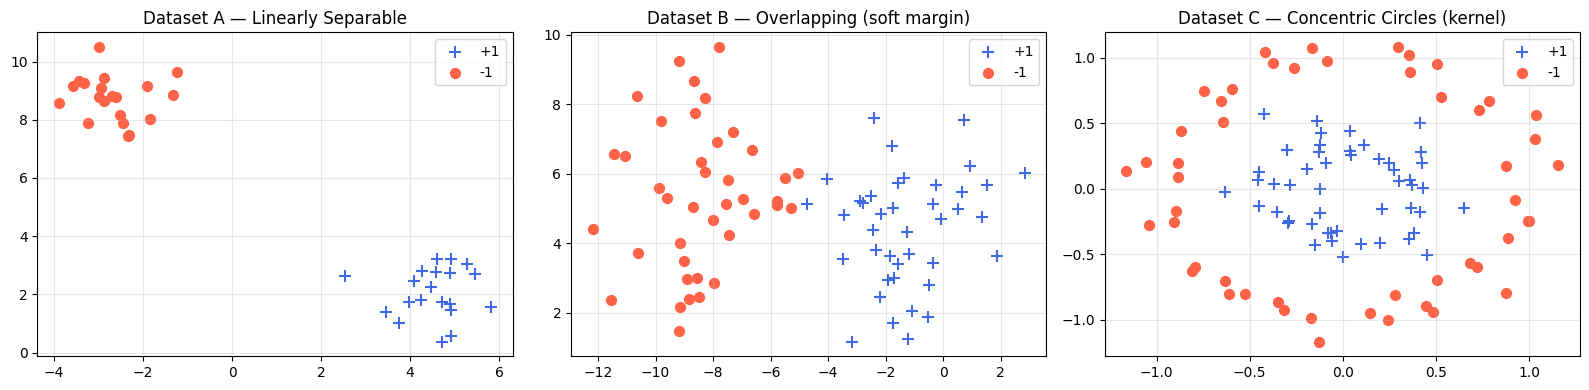

In [20]:
np.random.seed(42)

# ── Dataset A: linearly separable (hard margin) ──────────────────────────────
X_hard, y_hard_raw = make_blobs(n_samples=40, centers=2, random_state=42, cluster_std=0.8)
# SVM uses labels in {-1, +1} — sklearn make_blobs returns {0, 1}
y_hard = np.where(y_hard_raw == 0, -1, 1).astype(float)

# ── Dataset B: overlapping blobs (soft margin) ───────────────────────────────
X_soft, y_soft_raw = make_blobs(n_samples=80, centers=2, random_state=7, cluster_std=1.8)
y_soft = np.where(y_soft_raw == 0, -1, 1).astype(float)

# ── Dataset C: concentric circles (kernel SVM) ───────────────────────────────
# Linearly inseparable by construction — ideal for showcasing the kernel trick
from sklearn.datasets import make_circles
X_circ, y_circ_raw = make_circles(n_samples=100, noise=0.1, factor=0.4, random_state=42)
y_circ = np.where(y_circ_raw == 0, -1, 1).astype(float)

# ── Quick visualisation ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, X, y, title in [
    (axes[0], X_hard, y_hard,  "Dataset A — Linearly Separable"),
    (axes[1], X_soft, y_soft,  "Dataset B — Overlapping (soft margin)"),
    (axes[2], X_circ, y_circ,  "Dataset C — Concentric Circles (kernel)"),
]:
    ax.scatter(X[y==+1, 0], X[y==+1, 1], c='royalblue', marker='+', s=80, label='+1')
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c='tomato',    marker='o', s=50, label='-1')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Hard-Margin SVM — Derivation

### Primal problem

$$\min_{\vec{w},b} \frac{1}{2}\|\vec{w}\|^2 \quad \text{subject to} \quad y_i(\vec{w}\vec{x}_i + b) \geq 1$$

### Lagrangian

Introducing multipliers $\alpha_i \geq 0$ for each constraint:

$$L = \frac{1}{2}\|\vec{w}\|^2 + \sum_i \alpha_i\bigl(1 - y_i(\vec{w}\vec{x}_i + b)\bigr)$$

Setting partial derivatives to zero:
$$\frac{\partial L}{\partial \vec{w}} = 0 \implies \vec{w} = \sum_i \alpha_i y_i \vec{x}_i$$
$$\frac{\partial L}{\partial b} = 0 \implies \sum_i \alpha_i y_i = 0$$

### Dual problem (what we actually solve)

Substituting back, the Lagrangian simplifies to:

$$L = \sum_i \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j \vec{x}_i \vec{x}_j$$

We want to **maximise** this, equivalently **minimise** $-L$, subject to:
$$\alpha_i \geq 0, \quad \sum_i \alpha_i y_i = 0$$

### Recovering the decision boundary

Once $\alpha_i$ are found:
$$\vec{w} = \sum_i \alpha_i y_i \vec{x}_i$$
$$b = y_{sv} - \vec{w}\vec{x}_{sv} \quad \text{(using any support vector)}$$

**Support vectors** are the points with $\alpha_i > 0$.

### Mapping to `cvxopt.solvers.qp`

`cvxopt` solves:

$$\min_x (\frac{1}{2} x^T P x + q^T x) \quad \text{s.t.} \quad Gx \preceq h,\; Ax = b$$

Our mapping for the hard-margin dual:

| `cvxopt` | SVM dual |
|---|---|
| $x$ | $\alpha$ (the $n$ Lagrange multipliers) |
| $P_{ij}$ | $y_i y_j \vec{x}_i \cdot \vec{x}_j$ |
| $q$ | $-\mathbf{1}$ |
| $G$ | $-I$ (encodes $\alpha_i \geq 0$) |
| $h$ | $\mathbf{0}$ |
| $A$ | $y^T$ |
| $b$ | $0$ |

### Implementation

In [21]:
def hard_margin_svm(X, y):
    """
    Hard-Margin SVM via the dual QP formulation.

    Solves:   min  0.5 * alpha^T P alpha + q^T alpha
              s.t. G alpha <= h
                   A alpha  = b_eq

    where  P_ij = y_i * y_j * (x_i . x_j),  q = -1,
           G = -I  (alpha_i >= 0),
           A = y^T,  b_eq = 0.

    Returns: alphas, w, b, support_vector_indices
    """
    n = X.shape[0]

    # ── Build the QP matrices ─────────────────────────────────────────────────
    # P_ij = y_i * y_j * <x_i, x_j>   (outer product trick)
    P = np.outer(y, y) * (X @ X.T)        # shape (n, n) yiyj*(xi ⋅ xj)     TODO
    q = -np.ones(n)                        # we want to maximise sum(alpha), so minimise -sum   TODO

    G = -np.eye(n)                         # -alpha_i <= 0  ⟺  alpha_i >= 0 TODO
    h = np.zeros(n)                         #TODO

    A = y.reshape(1, -1)                   # equality: sum(alpha_i y_i) = 0 TODO
    b_eq = np.zeros(1)                      #TODO

    # ── Solve with cvxopt ─────────────────────────────────────────────────────
    # NOTE: cvxopt requires float64 matrices — cast with tc='d'
    sol = cvxopt_solvers.qp(
        cvxopt_matrix(P,    tc='d'),
        cvxopt_matrix(q,    tc='d'),
        cvxopt_matrix(G,    tc='d'),
        cvxopt_matrix(h,    tc='d'),
        cvxopt_matrix(A,    tc='d'),
        cvxopt_matrix(b_eq, tc='d'),
    )

    alphas = np.array(sol['x']).flatten()

    # ── Identify support vectors ──────────────────────────────────────────────
    # Support vectors have alpha_i > 0 (numerically: above a small threshold)
    threshold = 1e-5
    sv_mask    = alphas > threshold
    sv_indices = np.where(sv_mask)[0]
    sv_X       = X[sv_mask]
    sv_y       = y[sv_mask]
    sv_alpha   = alphas[sv_mask]

    # ── Recover w: w = sum_i alpha_i y_i x_i ─────────────────────────────────
    w = (sv_alpha * sv_y) @ sv_X          # shape (n_features,) w=i∑​αi​yi​xi​    TODO

    # ── Recover b: y_sv = w . x_sv + b  =>  b = mean over all SVs ───────────
    b = float(np.mean(sv_y - sv_X @ w))  #yi​(w⋅xi​+b)=1 ->b=yi​−w⋅xi​     TODO

    return alphas, w, b, sv_indices

### Visualisation

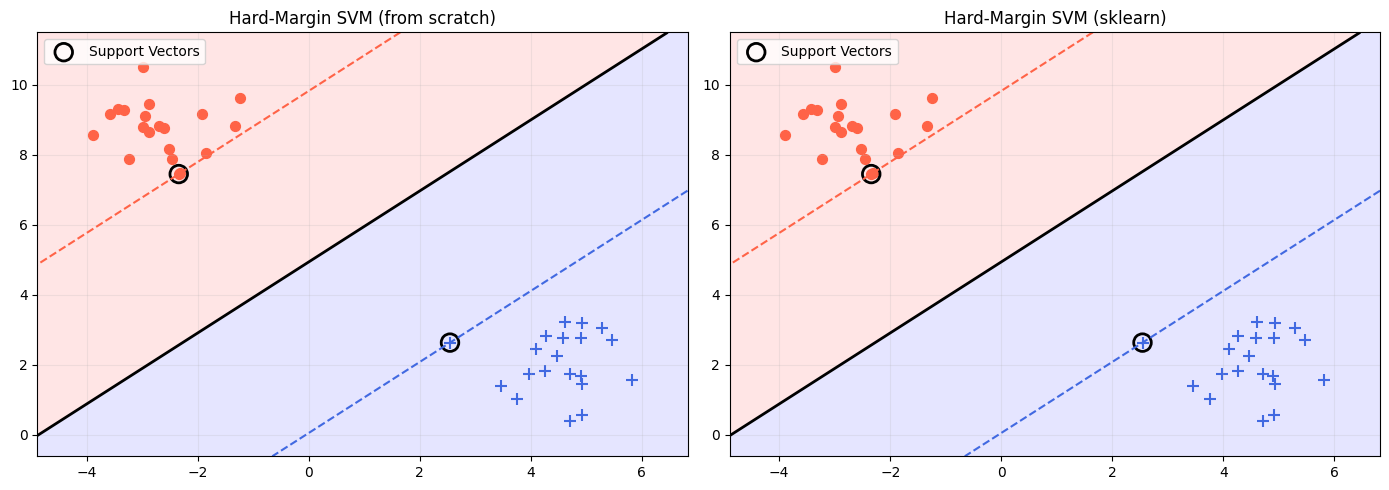

In [22]:
def plot_decision_boundary(ax, X, y, w, b, sv_indices, title, kernel_pred_fn=None):
    """
    Plot data points, decision boundary, and margin gutters.
    For non-linear kernels, kernel_pred_fn(xx) returns raw decision values on a grid.
    """
    # ── Grid for filled contour ───────────────────────────────────────────────
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if kernel_pred_fn is not None:
        # Non-linear: use the kernel decision function on the grid
        Z = kernel_pred_fn(grid).reshape(xx.shape)
    else:
        # Linear: w . x + b
        Z = (grid @ w + b).reshape(xx.shape)

    # Filled regions
    ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9],
                colors=['#ffaaaa', '#aaaaff'], alpha=0.3)
    # Decision boundary (Z=0) and margin gutters (Z=±1)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               linestyles=['--', '-', '--'],
               colors=['tomato', 'black', 'royalblue'], linewidths=[1.5, 2, 1.5])

    # Data points
    ax.scatter(X[y==+1, 0], X[y==+1, 1], c='royalblue', marker='+', s=80)
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c='tomato',    marker='o', s=50)

    # Support vectors circled
    ax.scatter(X[sv_indices, 0], X[sv_indices, 1],
               s=160, facecolors='none', edgecolors='black', linewidths=2,
               label='Support Vectors')

    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.2)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(axes[0], X_hard, y_hard, w_hm, b_hm, sv_idx_hm,
                       "Hard-Margin SVM (from scratch)")

# sklearn version for side-by-side comparison
w_sk = clf_hm.coef_[0]
b_sk = clf_hm.intercept_[0]
plot_decision_boundary(axes[1], X_hard, y_hard, w_sk, b_sk, clf_hm.support_,
                       "Hard-Margin SVM (sklearn)")

plt.tight_layout()
plt.show()

## 4. Soft-Margin SVM

When data is **not perfectly separable**, we introduce slack variables $\xi_i \geq 0$
to allow some misclassification:

$$y_i(\vec{w}\vec{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

The objective becomes:
$$\min_{\vec{w},b,\xi} \frac{1}{2}\|\vec{w}\|^2 + C\sum_i \xi_i$$

$C > 0$ is a **regularisation parameter**:
- **Large $C$**: penalise misclassifications heavily → narrow margin, less regularisation
- **Small $C$**: tolerate more violations → wide margin, more regularisation

### Dual problem (soft margin)

The dual is almost identical to the hard-margin case, but $\alpha_i$ is now **bounded**:

$$\sum_i \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j \vec{x}_i \vec{x}_j$$

subject to:
$$0 \leq \alpha_i \leq C, \quad \sum_i \alpha_i y_i = 0$$

The only change vs hard margin: $G$ and $h$ gain the upper-bound rows $\alpha_i \leq C$.

In [23]:
def soft_margin_svm(X, y, C=1.0):
    """
    Soft-Margin SVM via the dual QP formulation.

    Same as hard-margin, but alpha_i is now bounded: 0 <= alpha_i <= C.
    This is achieved by appending a second block to G and h:

        G = [ -I ]   h = [  0  ]
            [  I ]       [C*1  ]

    i.e.  -alpha_i <= 0     (lower bound)
           alpha_i <= C     (upper bound)

    Returns: alphas, w, b, support_vector_indices
    """
    n = X.shape[0]

    P = np.outer(y, y) * (X @ X.T)
    q = -np.ones(n)

    # Box constraints: 0 <= alpha_i <= C
    G = np.vstack([-np.eye(n), np.eye(n)])   # shape (2n, n)    TODO
    h = np.hstack([np.zeros(n), np.ones(n) * C])    #TODO

    A    = y.reshape(1, -1)
    b_eq = np.zeros(1)

    sol = cvxopt_solvers.qp(
        cvxopt_matrix(P,    tc='d'),
        cvxopt_matrix(q,    tc='d'),
        cvxopt_matrix(G,    tc='d'),
        cvxopt_matrix(h,    tc='d'),
        cvxopt_matrix(A,    tc='d'),
        cvxopt_matrix(b_eq, tc='d'),
    )

    alphas = np.array(sol['x']).flatten()

    threshold  = 1e-5
    sv_mask    = alphas > threshold
    sv_indices = np.where(sv_mask)[0]
    sv_X       = X[sv_mask]
    sv_y       = y[sv_mask]
    sv_alpha   = alphas[sv_mask]

    w = (sv_alpha * sv_y) @ sv_X

    # For b: use only the "free" support vectors (alpha_i strictly < C)
    # These lie exactly on the margin gutters, giving the most numerically stable b.
    free_mask = (alphas > threshold) & (alphas < C - threshold)
    if free_mask.sum() > 0:
        b = float(np.mean(y[free_mask] - X[free_mask] @ w))
    else:
        b = float(np.mean(sv_y - sv_X @ w))  #All the SV, not only the ones on the margin

    return alphas, w, b, sv_indices

### Results on Dataset B — varying C

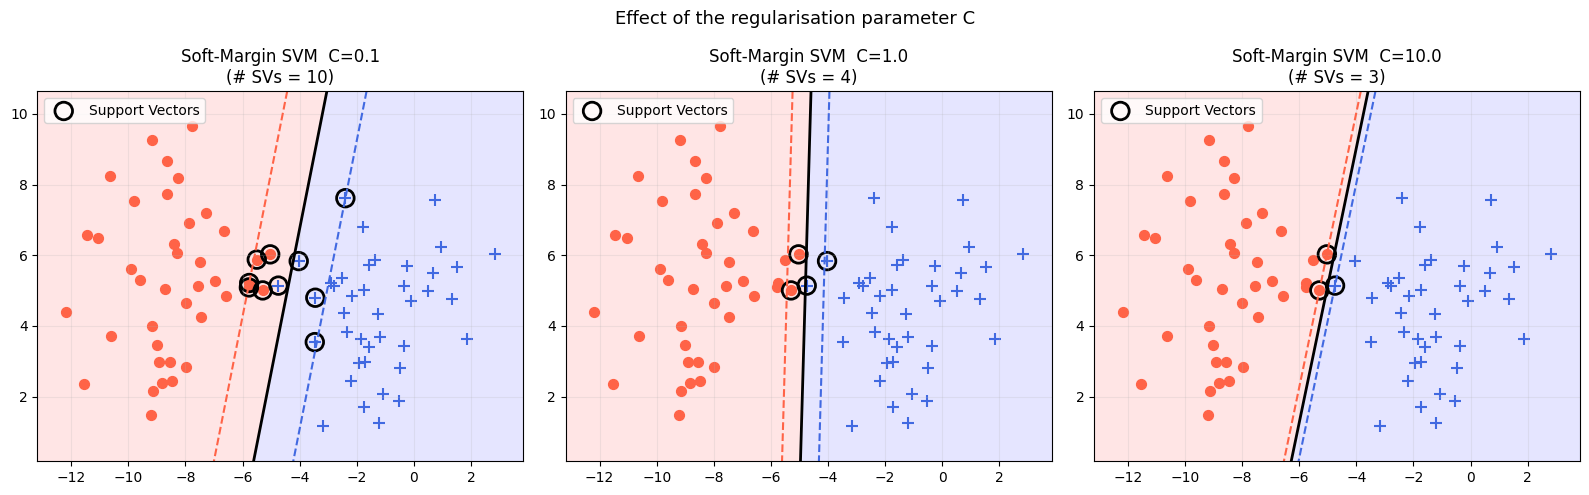

In [24]:
C_values = [0.1, 1.0, 10.0]
fig, axes = plt.subplots(1, len(C_values), figsize=(16, 5))

for ax, C in zip(axes, C_values):
    alphas_sm, w_sm, b_sm, sv_idx_sm = soft_margin_svm(X_soft, y_soft, C=C)
    plot_decision_boundary(ax, X_soft, y_soft, w_sm, b_sm, sv_idx_sm,
                           f"Soft-Margin SVM  C={C}\n(# SVs = {len(sv_idx_sm)})")

plt.suptitle("Effect of the regularisation parameter C", fontsize=13)
plt.tight_layout()
plt.show()

### Comparison with sklearn (C = 1.0)

In [25]:
C_test = 1.0
alphas_sm, w_sm, b_sm, sv_idx_sm = soft_margin_svm(X_soft, y_soft, C=C_test)

y_soft_sk = np.where(y_soft == -1, 0, 1)
clf_sm = svm.SVC(kernel='linear', C=C_test)
clf_sm.fit(X_soft, y_soft_sk)

print("=== Soft-Margin SVM (from scratch, C=1.0) ===")
print(f"  w              : {w_sm}")
print(f"  b              : {b_sm:.6f}")
print(f"  Support vectors: {sv_idx_sm}")

print()
print("=== sklearn SVC (C=1.0) ===")
print(f"  w              : {clf_sm.coef_[0]}")
print(f"  b              : {clf_sm.intercept_[0]:.6f}")
print(f"  Support vectors: {clf_sm.support_}")

print()
print("=== Comparison ===")
print(f"  Δw  : {np.abs(w_sm - clf_sm.coef_[0])}")
print(f"  Δb  : {abs(b_sm - clf_sm.intercept_[0]):.4f}")
print(f"  Same SV set?  {set(sv_idx_sm) == set(clf_sm.support_)}")

=== Soft-Margin SVM (from scratch, C=1.0) ===
  w              : [ 1.54843581 -0.05464238]
  b              : 7.696524
  Support vectors: [ 4 30 37 43]

=== sklearn SVC (C=1.0) ===
  w              : [ 1.54843581 -0.05464238]
  b              : 7.517982
  Support vectors: [30 37  4 43]

=== Comparison ===
  Δw  : [7.97344413e-11 5.25295363e-11]
  Δb  : 0.1785
  Same SV set?  True


## 5. The Kernel Trick

The dual objective only involves **dot products** $\vec{x}_i \cdot \vec{x}_j$.
We can replace these with a **kernel function**:

$$K(\vec{x}_i, \vec{x}_j) = \phi(\vec{x}_i) \cdot \phi(\vec{x}_j)$$

where $\phi$ maps data into a higher-dimensional feature space.  
We never compute $\phi$ explicitly — we only need $K$.

### Polynomial Kernel

$$K(\vec{x}_i, \vec{x}_j) = (\vec{x}_i \cdot \vec{x}_j + c)^d$$

Intuition: implicitly maps the original features to all polynomial combinations up to degree $d$.

### Applying the kernel: just replace dot products

In the dual objective:
$$L = \sum_i \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j \underbrace{\vec{x}_i \vec{x}_j}_{\text{replace with }K(\vec{x}_i,\vec{x}_j)}$$

The decision rule becomes:
$$f(\vec{x}) = \text{sign}\!\left(\sum_i \alpha_i y_i K(\vec{x}_i, \vec{x}) + b\right)$$

In [26]:
def polynomial_kernel(X1, X2, degree=2, coef0=1.0):
    """
    Polynomial kernel: K(x_i, x_j) = (x_i . x_j + coef0)^degree

    - degree=1, coef0=0  → linear kernel (reduces to a dot product)
    - degree=2, coef0=1  → quadratic kernel (captures interactions and squares)
    """
    return (X1 @ X2.T + coef0) ** degree #TODO


def kernel_svm(X, y, kernel_fn, C=1.0):
    """
    Kernel Soft-Margin SVM.

    The QP structure is identical to the linear soft-margin SVM, but the
    Gram matrix P is computed using the kernel function instead of the dot product:

        P_ij = y_i * y_j * K(x_i, x_j)

    After solving, we recover b from the margin support vectors using
    the kernel evaluation (no explicit w in feature space needed).

    Returns: alphas, sv_X, sv_y, sv_alpha, b
    """
    n = X.shape[0]

    # ── Gram matrix via kernel ────────────────────────────────────────────────
    K = kernel_fn(X, X)                     # shape (n, n)  TODO
    P = np.outer(y, y) * K                  #TODO

    q    = -np.ones(n)
    G    = np.vstack([-np.eye(n), np.eye(n)])
    h    = np.hstack([np.zeros(n), np.ones(n) * C])
    A    = y.reshape(1, -1)
    b_eq = np.zeros(1)

    sol = cvxopt_solvers.qp(
        cvxopt_matrix(P,    tc='d'),
        cvxopt_matrix(q,    tc='d'),
        cvxopt_matrix(G,    tc='d'),
        cvxopt_matrix(h,    tc='d'),
        cvxopt_matrix(A,    tc='d'),
        cvxopt_matrix(b_eq, tc='d'),
    )

    alphas = np.array(sol['x']).flatten()

    threshold  = 1e-5
    sv_mask    = alphas > threshold
    sv_X       = X[sv_mask]
    sv_y       = y[sv_mask]
    sv_alpha   = alphas[sv_mask]

    # ── Recover b using free support vectors ──────────────────────────────────
    # f(x_sv) = sum_i alpha_i y_i K(x_i, x_sv) + b = y_sv  (for margin SVs)
    free_mask = (alphas > threshold) & (alphas < C - threshold)  #points on margin
    K_free_sv = kernel_fn(X[free_mask], sv_X)   # shape (n_free, n_sv)   calculate K
    f_free    = (sv_alpha * sv_y) @ K_free_sv.T  # decision values (no b)   ∑j​αj​yj​K(xj​,xi​) for each SV
    b         = float(np.mean(y[free_mask] - f_free))

    return alphas, sv_X, sv_y, sv_alpha, b


def kernel_decision_fn(X_test, sv_X, sv_y, sv_alpha, b, kernel_fn):
    """
    Evaluate the SVM decision function on test points:
        f(x) = sum_i alpha_i y_i K(x_i, x) + b
    """
    K = kernel_fn(X_test, sv_X)                  # shape (n_test, n_sv)
    return (sv_alpha * sv_y) @ K.T + b

### Results — Polynomial Kernel (degree 2) on Dataset B

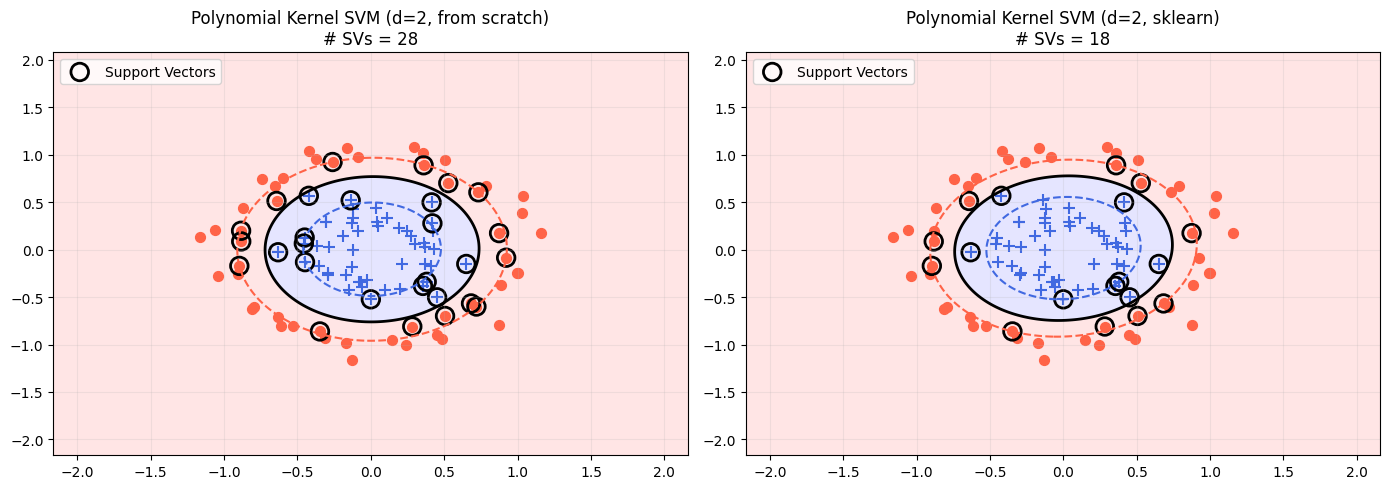

Train accuracy — from scratch : 1.000
Train accuracy — sklearn      : 1.000


In [27]:
# Degree-2 polynomial kernel with coef0=1
kernel_fn_d2 = lambda X1, X2: polynomial_kernel(X1, X2, degree=2, coef0=1.0) #parameters for the kernelization

C_kernel = 1.0
alphas_k, sv_X_k, sv_y_k, sv_a_k, b_k = kernel_svm(X_circ, y_circ, kernel_fn_d2, C=C_kernel) #kernelization  TODOMAYBE
sv_mask_k = np.zeros(len(X_circ), dtype=bool) #coorinates of support vectors for the plot
sv_mask_k[np.where(alphas_k > 1e-5)[0]] = True
sv_idx_k   = np.where(sv_mask_k)[0]

# Decision function for plotting
pred_fn = lambda X_test: kernel_decision_fn(X_test, sv_X_k, sv_y_k, sv_a_k, b_k, kernel_fn_d2)  #TODOMAYBE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# From-scratch kernel SVM
plot_decision_boundary(axes[0], X_circ, y_circ, None, None, sv_idx_k,
                       f"Polynomial Kernel SVM (d=2, from scratch)\n# SVs = {len(sv_idx_k)}",
                       kernel_pred_fn=pred_fn)

# sklearn for comparison
y_circ_sk = np.where(y_circ == -1, 0, 1)
clf_poly = svm.SVC(kernel='poly', degree=2, coef0=1.0, C=C_kernel)
clf_poly.fit(X_circ, y_circ_sk)
sk_pred_fn = lambda X_test: clf_poly.decision_function(X_test)
plot_decision_boundary(axes[1], X_circ, y_circ, None, None, clf_poly.support_,
                       f"Polynomial Kernel SVM (d=2, sklearn)\n# SVs = {len(clf_poly.support_)}",
                       kernel_pred_fn=sk_pred_fn)

plt.tight_layout()
plt.show()

# Accuracy
y_pred_scratch = np.sign(pred_fn(X_circ))
y_pred_sk      = np.where(clf_poly.predict(X_circ) == 0, -1, 1)
print(f"Train accuracy — from scratch : {np.mean(y_pred_scratch == y_circ):.3f}")
print(f"Train accuracy — sklearn      : {np.mean(y_pred_sk      == y_circ):.3f}")

### Effect of polynomial degree

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


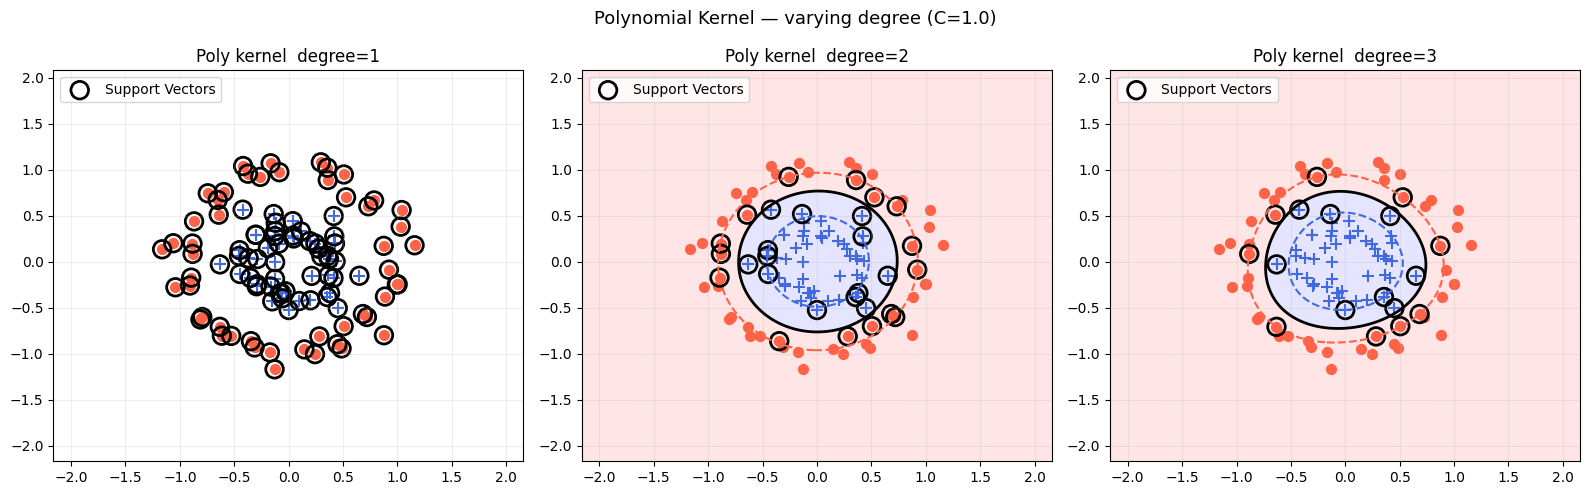

In [28]:
degrees = [1, 2, 3]
fig, axes = plt.subplots(1, len(degrees), figsize=(16, 5))

for ax, d in zip(axes, degrees):
    kfn = lambda X1, X2, d=d: polynomial_kernel(X1, X2, degree=d, coef0=1.0)
    alpha_d, sv_X_d, sv_y_d, sv_a_d, b_d = kernel_svm(X_circ, y_circ, kfn, C=1.0)
    pred_d = lambda X_test, sv_X=sv_X_d, sv_y=sv_y_d, sv_a=sv_a_d, b=b_d, kfn=kfn: \
        kernel_decision_fn(X_test, sv_X, sv_y, sv_a, b, kfn)
    sv_idx_d = np.where(alpha_d > 1e-5)[0]
    plot_decision_boundary(ax, X_circ, y_circ, None, None, sv_idx_d,
                           f"Poly kernel  degree={d}", kernel_pred_fn=pred_d)

plt.suptitle("Polynomial Kernel — varying degree (C=1.0)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Summary

| Method | Kernel | Margin | Key parameter |
|---|---|---|---|
| Hard-Margin SVM | Linear ($\vec{x}_i \cdot \vec{x}_j$) | Hard | — |
| Soft-Margin SVM | Linear | Soft | $C$ |
| Kernel SVM | Polynomial $(\vec{x}_i \cdot \vec{x}_j + c)^d$ | Soft | $C$, $d$ |

**All three** are solved using the same QP structure via `cvxopt.solvers.qp`. The only differences are:
1. Hard → soft margin: add the upper-bound constraint $\alpha_i \leq C$
2. Linear → kernel: replace the Gram matrix $XX^T$ with $K(X, X)$

---
## ✏️  Live Coding Sections

The following cells are intentionally **left incomplete** to be written live during the lecture.
Below is a guide for the presenter:

### Section 3 — Hard-Margin SVM (`hard_margin_svm`)
**Remove** the body of `hard_margin_svm` (keep docstring + variable names as scaffolding).
Walk through:
1. Building `P` (`np.outer` + dot products)
2. Setting up `G`, `h`, `A`, `b_eq`
3. Calling `cvxopt_solvers.qp`
4. Extracting `w` and `b` from `alphas`

### Section 4 — Soft-Margin SVM (`soft_margin_svm`)
**Remove** only the `G`/`h` construction (upper-bound block).
Ask audience: *what changes vs hard margin?*

### Section 5 — Polynomial Kernel (`polynomial_kernel` + `kernel_decision_fn`)
**Remove** the one-line body of `polynomial_kernel`.
Ask audience: *how does the kernel change the Gram matrix `P`?*